In [1]:
import numpy as np
import pandas as pd
from pysam import VariantFile
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
%matplotlib inline
import seaborn as sns
sns.set_style("whitegrid")
import os
import geopandas as gpd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Patch

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split"
dftisa = pd.read_csv(f'{path}/../tissue40.list', sep='\t')
tisorder = pd.read_csv("/storage/public/home/2020060185/jupyter/GTEx/00.metadata/tissue.order",sep="\t")
palette = tisorder.set_index('Tissue (QTL)')['Color'].to_dict()

In [3]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v9.breed_specific"
dftis = pd.read_csv(f'{path}/v1.anc/tissue.filtered2.list', sep='\t')
tislist = list(dftis['Tissue'])
dfanc = pd.melt(dftis, id_vars=['Tissue'], value_vars=['Europe', 'Central_and_East_Asia'], 
           var_name='group', value_name='Sample size')
dfbred = pd.read_csv(f'{path}/v2.breed/k.txt', sep='\t', header=None, usecols=[0,1,4],
                     names=['Tissue','breed','Sample size']).rename(columns={'breed':'group'})
dfall = dftisa.loc[dftisa['Tissue'].isin(tislist), ['Tissue','Sample size']]
dfall['group'] = 'All'
dftis = pd.concat([dfall, dfanc, dfbred])
dftis

,Tissue,Sample size,group
0,Muscle,713,All
1,Liver,567,All
2,Adipose,491,All
3,Brain,481,All
4,Longissimus_muscle,419,All
...,...,...,...
24,Abomasum,43,Hu
25,Abomasum,49,Merino
26,Heart,59,Hu
27,Heart,44,Small-tailed_Han


# Fig. 6b

In [4]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v9.breed_specific/v1.anc"
df_fd = pd.read_csv(f'{path}/fd_eqtl.txt', sep='\t')
df_fd['type'] = 'fd-QTL'
df_ld = pd.read_csv(f'{path}/ld_eqtl.txt', sep='\t')
df_ld['type'] = 'ld-QTL'
df_he = pd.read_csv(f'{path}/he_eqtl.txt', sep='\t')
df_he['type'] = 'he-QTL'

In [6]:
df_egene = pd.concat([df_fd[['tissue','pheno_id','type']],df_ld[['tissue','pheno_id','type']],df_he[['tissue','pheno_id','type']]]).drop_duplicates()
df_egene_count = df_egene.groupby(['tissue','type']).count().reset_index().sort_values(by='pheno_id', ascending=False)
df_egene_count_pivot = df_egene_count.pivot_table(index='tissue', columns='type', values='pheno_id', aggfunc='sum', fill_value=0)
df_egene_count_pivot = df_egene_count_pivot.merge(tisorder[['System', 'Tissue (QTL)', 'Color']].rename(columns={'Tissue (QTL)':'tissue'}), on='tissue')
df_egene_count_pivot['tissue'] = df_egene_count_pivot['tissue'].replace('_', ' ', regex=True)
df_egene_count_pivot = df_egene_count_pivot.set_index('tissue')
row_order = df_egene_count_pivot[['fd-QTL','ld-QTL','he-QTL']].sum(axis=1).sort_values(ascending=False).index.tolist()
df_egene_count_pivot = df_egene_count_pivot.reindex(row_order)
df_egene_count_pivot

,fd-QTL,he-QTL,ld-QTL,System,Color
tissue,,,,,
Liver,190,84,145,Digestive system,#ad8c8b
Rumen,180,64,103,Digestive system,#fc9891
Adipose,154,34,149,Endocrine system,#ffc4f1
Pituitary,174,94,54,Nervous system,#f1d95d
Muscle,145,51,110,Muscular system,#a180ca
Uterus,166,31,97,Female reproductive system,#8bc774
Longissimus muscle,100,61,97,Muscular system,#754fa4
Brain,95,41,87,Nervous system,#d4dc23
Lung,121,21,60,Respiratory system,#36b5f1


In [7]:
df_egene_count_pivot_stat = df_egene_count_pivot[['fd-QTL','ld-QTL','he-QTL']].copy()
df_egene_count_pivot_stat['sum'] = df_egene_count_pivot_stat.sum(axis=1)
df_egene_count_pivot_stat

,fd-QTL,ld-QTL,he-QTL,sum
tissue,,,,
Liver,190,145,84,419
Rumen,180,103,64,347
Adipose,154,149,34,337
Pituitary,174,54,94,322
Muscle,145,110,51,306
Uterus,166,97,31,294
Longissimus muscle,100,97,61,258
Brain,95,87,41,223
Lung,121,60,21,202


In [9]:
df_egene_count_pivot_stat.mean()

fd-QTL    113.285714
ld-QTL     79.714286
he-QTL     40.571429
sum       233.571429
dtype: float64

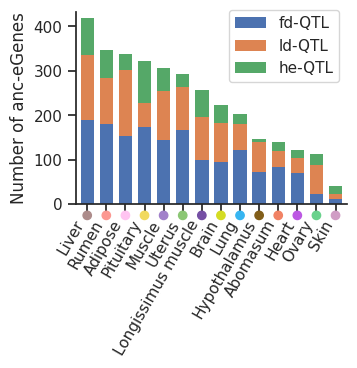

In [7]:
sns.set_theme(style="ticks")
fig=plt.figure(figsize=(3.5, 2.5))
ax = fig.add_subplot()

df_egene_count_pivot[['fd-QTL','ld-QTL','he-QTL']].plot(kind='bar', stacked=True, ax=ax, linewidth=0, width=0.7)
ax.scatter(np.arange(df_egene_count_pivot.shape[0]), -25*np.ones(df_egene_count_pivot.shape[0]), c=df_egene_count_pivot['Color'], clip_on=False)
ax.set_ylim([0, df_egene_count_pivot[['fd-QTL','ld-QTL','he-QTL']].max().sum()])
ax.tick_params(axis='x', which='major')
plt.ylabel(f'Number of anc-eGenes')
sns.move_legend(ax, "upper right", bbox_to_anchor=(1, 1.05), title=None)
plt.xticks(rotation=60, ha='right')
plt.xlabel('')
sns.despine()
plt.savefig("pdf/ancqtl_tissue.pdf", bbox_inches='tight')

# Fig. 6c-e

## functions1

In [ ]:
def load_qtl(nominal_file, perm_file, plink_prefix, ld_prefix, phenotype_id, variant_id=None, x_axis_range=None):
    ## input summary data
    nominal_df = pd.read_csv(nominal_file, sep='\t')
    nominal_df = nominal_df[nominal_df['phenotype_id']==phenotype_id]
    nominal_df = nominal_df.dropna(subset=['pval_nominal'])
    if nominal_df.empty:
        warnings.warn("No valid pval_nominal values found for the specified phenotype_id.")
        return pd.DataFrame(), None, variant_id
    perm_df = pd.read_csv(perm_file, sep='\t')
    pval_nominal_threshold = perm_df[perm_df['phenotype_id']==phenotype_id]['pval_nominal_threshold'].values[0]

    ## input bim file
    bim_file = f'{plink_prefix}.bim'
    bim_df = pd.read_csv(bim_file, delim_whitespace=True, header=None, names=['CHR', 'SNP', 'CM', 'BP', 'ALT', 'REF'])

    ## merge data
    merged_nominal_df = pd.merge(nominal_df, bim_df, left_on='variant_id', right_on='SNP', how='left')

    # get the top snp
    if variant_id:
        if variant_id in merged_nominal_df['variant_id'].values:
            top_snp = variant_id
            top_snp_row = merged_nominal_df[merged_nominal_df['variant_id']==top_snp].iloc[0]
        else:
            warnings.warn(f"The specified SNP {variant_id} is not in the nominal results.")
            return pd.DataFrame(), pval_nominal_threshold, variant_id
    else:
        top_snp_row = merged_nominal_df.loc[merged_nominal_df['pval_nominal'].idxmin()]
        top_snp = top_snp_row['variant_id']
        variant_id = top_snp
    top_bp = int(top_snp_row['BP'])

    # compute LD
    if not os.path.isfile(f'{ld_prefix}.{variant_id}.ld'):
        cmd=f'''/storage/public/home/2020060185/bin/plink \\
            --bfile {plink_prefix} --ld-snp {top_snp} \\
            --sheep --keep-allele-order --r2 yes-really \\
            --ld-window-kb 999999 --ld-window 999999 --ld-window-r2 0 \\
            --out {ld_prefix}.{variant_id}'''
        os.system(cmd)
    ld_df = pd.read_csv(f'{ld_prefix}.{variant_id}.ld', delim_whitespace=True)
    ld_df = ld_df[['SNP_B', 'R2']]
    ld_df.columns = ['SNP', 'R2']
    ## merge data
    merged_df = pd.merge(merged_nominal_df, ld_df, left_on='variant_id', right_on='SNP', how='left')

    # set x axis range
    if x_axis_range:
        range_start = top_bp - x_axis_range
        range_end = top_bp + x_axis_range
        merged_df = merged_df[(merged_df['BP'] >= range_start) & (merged_df['BP'] <= range_end)]

    # prepare data for locusplot
    locuszoom_df = merged_df[['phenotype_id','variant_id','slope', 'slope_se', 'pval_nominal','BP','R2']].copy()
    locuszoom_df['-log10(p-value)'] = -np.log10(locuszoom_df['pval_nominal'])
    locuszoom_df = locuszoom_df.sort_values(by='R2', ascending=True)
    
    return locuszoom_df, pval_nominal_threshold, variant_id

In [ ]:
def load_group_tpm(tpm, vcf_file, group_file, phenotype_id, variant_id):
    if not variant_id:
        warnings.warn(f"Variant {variant_id} does not exist!")
    chrom = 'chr' + variant_id.split('_')[0]
    position = int(variant_id.split('_')[1])
    # input genotpyes
    vcf_in = VariantFile(vcf_file)  # auto-detect input format

    rec_list = []
    for rec in vcf_in.fetch(chrom, position-1, position):
        rec_dict = {
            'chrom': rec.chrom,
            'pos': rec.pos,
            'id': rec.id,
            'ref': rec.ref,
            'alt': rec.alts[0]
        }
        for sample in rec.samples:
            rec_dict[sample] = sum(rec.samples[sample]['GT'])
        rec_list.append(rec_dict)

    genotype_df = pd.DataFrame(rec_list)
    genotype_s = genotype_df[genotype_df['id']==variant_id].iloc[0]

    # input phenotypes
    sample_list = genotype_s.index[5:].to_list()
    phenotype_df = tpm[sample_list]
    phenotype_s = phenotype_df.loc[phenotype_id]
    
    # input group
    group_df = pd.read_csv(group_file, sep="\t", index_col=0)

    # grouping
    df = pd.DataFrame({
        'phenotype': phenotype_s,
        'genotype': genotype_s[5:]
    })
    df = pd.merge(df, group_df, left_index=True, right_index=True)
    df = df[df['phenotype']>0]
    df['genotype'] = df['genotype'].astype(int)
    
    # rename
    df['log\u2082(TPM)'] = np.log2(df['phenotype'])
    ref = genotype_s['ref'] + '/' + genotype_s['ref']
    het = genotype_s['ref'] + '/' + genotype_s['alt']
    alt = genotype_s['alt'] + '/' + genotype_s['alt']
    df['genotype0'] = df['genotype'].replace({0:ref, 1:het, 2:alt})
    df = df.sort_values(by='genotype', ascending=True)
    return df, genotype_s['ref'], genotype_s['alt']


def plot_compare_tpm(df, variant_id, figsize=(2.5, 2.5), title=None, legend=True, ax=None):
    if ax is None:
        sns.set_theme(style="ticks")
        fig, ax = plt.subplots(figsize=figsize)
    
    sns.stripplot(data=df, x='genotype0', y='log\u2082(TPM)', hue="group", hue_order=['EUR', 'CEA'],
                       alpha=0.5, dodge=True, legend=False, ax=ax)
    
    sns.boxplot(data=df, x='genotype0', y='log\u2082(TPM)', hue="group", hue_order=['EUR', 'CEA'],
                     gap=0.2, fill=False, legend=legend, showfliers=False, dodge=True, ax=ax)
    
    for i, group in enumerate(['EUR', 'CEA']): 
        sns.regplot(data=df[df['group']==group], x='genotype', y='log\u2082(TPM)',
                    scatter=None, color=sns.color_palette()[i], ax=ax)

    ax.set_xlabel(variant_id)
    if legend:
        sns.move_legend(ax, "lower left", title=None, ncols=2, bbox_to_anchor=(-0.5, -0.6))
    if title:
        ax.set_title(title)
        
    sns.despine()
    
    return ax

In [ ]:
def draw_pie(dist, xpos, ypos, size, color=None, ax=None):
    """A function to plot pie charts"""
    """https://stackoverflow.com/questions/56337732/how-to-plot-scatter-pie-chart-using-matplotlib"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,8))

    # for incremental pie slices
    cumsum = np.cumsum(dist)
    cumsum = cumsum/ cumsum[-1]
    pie = [0] + cumsum.tolist()
    for i, (r1, r2) in enumerate(zip(pie[:-1], pie[1:])):
        angles = np.linspace(2 * np.pi * r1, 2 * np.pi * r2)
        x = [0] + np.cos(angles).tolist()
        y = [0] + np.sin(angles).tolist()
        xy = np.column_stack([x, y])
        if color:
            c=color[i]
        ax.scatter([xpos], [ypos], marker=xy, s=size, c=c, linewidths=0)


def plot_map(df, ref, alt, variant_id, figsize=(7.5, 2.5), title=None, ax=None):
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    if ax is None:
        sns.set_theme(style="ticks")
        fig, ax = plt.subplots(figsize=figsize)
    world.plot(ax=ax, color='lightgray', edgecolor='none', linewidth=0)
    min_lon, max_lon = df['longitude'].min(), df['longitude'].max()
    min_lat, max_lat = df['latitude'].min(), df['latitude'].max()
    ax.set_xlim([min_lon - 10, max_lon + 10])
    ax.set_ylim([min_lat - 10, max_lat + 10])
    
    # plot pie
    for breed, group in df.groupby('breed'):
        lat, lon = group[['latitude', 'longitude']].mean() 
        if pd.notna(lat) and pd.notna(lon):
            alt_rate = group['genotype'].mean()/2
            ref_rate = 1 - alt_rate
            samplesize = group.shape[0]
            draw_pie(dist=[ref_rate, alt_rate], xpos=lon, ypos=lat, size=samplesize*5, color=sns.color_palette().as_hex()[0:2], ax=ax)
            
    # plot legend
    legend_elements = [plt.Rectangle((0,0), 1, 1, fc=sns.color_palette().as_hex()[0], label=ref), plt.Rectangle((0,0), 1, 1, fc=sns.color_palette().as_hex()[1], label=alt)]
    ax.legend(handles=legend_elements, ncols=2, loc='upper right', title=variant_id)
    if title:
        ax.set_title(title, pad=10)
    ax.set_axis_off()
    
    return ax, legend_elements

In [ ]:
def plot_compare_map_tpm(tpm_df1, ref1, alt1, tpm_df2, ref2, alt2, tissue, phenotype_id, top_snp1=None, top_snp2=None, figsize=(20,5)):
    sns.set_theme(style="ticks")
    fig, axes = plt.subplots(2, 2, figsize=figsize, gridspec_kw={'width_ratios': [5, 1]}, sharex=False, sharey=False)
    
    # plot1 (upper left)
    if tpm_df1.empty:
        warnings.warn("tpm_df1 is empty!")
    else:
        plot_map(tpm_df1, ref1, alt1, top_snp1, title=f'{phenotype_id} in {tissue}', ax=axes[0,0])

    # plot2 (upper right)
    if tpm_df1.empty:
        warnings.warn("tpm_df1 is empty!")
    else:
        plot_compare_tpm(tpm_df1, top_snp1, title=f'{phenotype_id} in {tissue}', legend=False, ax=axes[0,1])
    
    # plot3 (lower left)
    if tpm_df1.empty:
        warnings.warn("tpm_df2 is empty!")
    else:
        plot_map(tpm_df2, ref2, alt2, top_snp2, title=f'{phenotype_id} in {tissue}', ax=axes[1,0])
        
    # plot4 (lower right)
    if tpm_df2.empty:
        warnings.warn("tpm_df2 is empty!")
    else:
        plot_compare_tpm(tpm_df2, top_snp2, title=f'{phenotype_id} in {tissue}', legend=True, ax=axes[1,1])

    plt.subplots_adjust(wspace=0)
    plt.subplots_adjust(hspace=0.5)
    

In [ ]:
def plot_locus(df, pval_nominal_threshold, title=None, top_snp=None, rsid=None, highlight_range=None, x_axis_range=None, xlabel=True, ylabel=True, y_axis_limit=None, ax=None):
    lz_colors = ["#282973", "#8CCCF0", "#69BD45", "#F9A41A", "#ED1F24"]
    cmap = mpl.colors.ListedColormap(lz_colors)
    bounds = np.arange(0,1.2,0.2)
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(2.5, 2.5))

    ## scatter plot
    ax.scatter(df['BP']/1e6, df['-log10(p-value)'],
               c=df['R2'], cmap=cmap, norm=norm, s=10, edgecolor=None)
    if y_axis_limit:
        ax.set_ylim(y_axis_limit)
    #else:
    #    ax.set_ylim(0, max(-np.log10(pval_nominal_threshold), df['-log10(p-value)'].max())*1.25)
        
    ## plot the top snp
    if not top_snp:
        top_snp = df.loc[df['pval_nominal'].idxmin()]['variant_id']
    top_snp_bp = df[df['variant_id'] == top_snp]['BP'].values[0]
    top_snp_p = df[df['variant_id'] == top_snp]['-log10(p-value)'].values[0]
    ax.scatter(top_snp_bp/1e6, top_snp_p, color='purple', marker='D', s=50, label='Top SNP', edgecolor='black')
    if x_axis_range:
        ax.set_xlim(x_axis_range)

    ## plot highlight range
    if highlight_range:
        ax.axvspan(xmin=highlight_range[0]/1e6, xmax=highlight_range[1]/1e6, color='gray', alpha=0.2)
            
    ## pvalue threshold
    ax.axhline(y=-np.log10(pval_nominal_threshold), color='red', linestyle='--')

    ## xticks and legend
    if title:
        ax.set_title(title, pad=0)
    chrom = df['variant_id'][0].split('_')[0].replace('chr', '')
    if ylabel:
        ax.set_ylabel(r"-log$_{10}P$")
    if rsid:
        ax.text(top_snp_bp/1e6, top_snp_p, rsid, fontsize=10, ha="center", va="bottom")
    else:
        ax.text(top_snp_bp/1e6, top_snp_p, top_snp, fontsize=10, ha="center", va="bottom")
    if xlabel:
        ax.set_xlabel(f"Position on chr{chrom} (Mb)")

    sns.despine()


def plot_compare_locus(locuszoom_df11, locuszoom_df12, locuszoom_df21, locuszoom_df22, pval_nominal_threshold1, pval_nominal_threshold2,
                       title1=None, title2=None, top_snp1=None, top_snp2=None, rsid1=None, rsid2=None, highlight_range=None, x_axis_range=None, y_axis_limit=None, figsize=(5, 5)):
    sns.set_theme(style="ticks")
    fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=True, sharey=True)
    
    # plot1 (upper left)
    if locuszoom_df11.empty:
        warnings.warn("locuszoom_df11 is empty!")
    elif top_snp1 in locuszoom_df11['variant_id'].values:
        plot_locus(locuszoom_df11, pval_nominal_threshold1, title=title1, top_snp=top_snp1, rsid=rsid1,
                   highlight_range=highlight_range, x_axis_range=x_axis_range, xlabel=False, y_axis_limit=y_axis_limit, ax=axes[0,0])
    else:
                warnings.warn(f"The specified SNP {top_snp1} is not in locuszoom_df11.")

    # plot2 (lower left)
    if locuszoom_df12.empty:
        warnings.warn("locuszoom_df12 is empty!")
    elif top_snp1 in locuszoom_df12['variant_id'].values:
        plot_locus(locuszoom_df12, pval_nominal_threshold1, title=title1, top_snp=top_snp2, rsid=rsid2,
                   highlight_range=highlight_range, x_axis_range=x_axis_range, y_axis_limit=y_axis_limit, ax=axes[1,0])
    else:
        warnings.warn(f"The specified SNP {top_snp2} is not in locuszoom_df12.")
        
    # plot3 (upper right)
    if locuszoom_df21.empty:
        warnings.warn("locuszoom_df21 is empty!")
    elif top_snp1 in locuszoom_df21['variant_id'].values:
        plot_locus(locuszoom_df21, pval_nominal_threshold2, title=title2, top_snp=top_snp1, rsid=rsid1,
                   highlight_range=highlight_range, x_axis_range=None, xlabel=False, ylabel=False, y_axis_limit=None, ax=axes[0,1])
    else:
        warnings.warn(f"The specified SNP {top_snp1} is not in locuszoom_df21.")

    # plot4 (lower right)
    if locuszoom_df22.empty:
        warnings.warn("locuszoom_df22 is empty!")
    elif top_snp1 in locuszoom_df22['variant_id'].values:
        plot_locus(locuszoom_df22, pval_nominal_threshold2, title=title2, top_snp=top_snp2,  rsid=rsid2,
                   highlight_range=highlight_range, x_axis_range=None, ylabel=False, y_axis_limit=None, ax=axes[1,1])
    else:
        warnings.warn(f"The specified SNP {top_snp2} is not in locuszoom_df22.")
        
    ## color bar
    lz_colors = ["#282973", "#8CCCF0", "#69BD45", "#F9A41A", "#ED1F24"]
    cmap = mpl.colors.ListedColormap(lz_colors)
    bounds = np.arange(0,1.2,0.2)
    norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
    
    cax = fig.add_axes([0.95, 0.4, 0.03, 0.15])
    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm,
                                   boundaries=bounds, ticks=bounds,
                                   spacing='proportional', orientation='vertical')
    cax.set_title(r'$r^{2}$', fontsize=12)
    cax.set_ylim([0,1])
    cax.tick_params(labelsize=10)
    
    fig.subplots_adjust(hspace=0.5)

In [39]:
#tpm_file = '/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/sheep.PCGlnc.gene.merged.tpm.txt'
#tpm = pd.read_csv(tpm_file, sep='\t', index_col=0)
#tpm

,BZCJ77_Heart,BZCJ77_Abomasum,BZCJ77_Cecum,BZCJ77_Colon,BZCJ77_Large_intestine,BZCJ77_Rectum,BZCJ77_Duodenum,BZCJ77_Small_intestine,BZCJ77_Ileum,BZCJ77_Jejunum,...,SAMN36788086_Artery,SAMN36788203_Artery,SAMN36788184_Artery,SAMN36788198_Artery,SAMN36788097_Artery,SAMN36788096_Artery,SAMN36778255_Ileum,SAMN36788077_Artery,SAMN36788076_Artery,SAMN36788224_Artery
Geneid,,,,,,,,,,,,,,,,,,,,,
LOC114112203,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
LOC114110836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
LOC114113923,0.968444,3.691410,0.538714,1.822510,2.084590,2.084590,0.569984,1.150510,1.150510,1.184440,...,5.657820,0.341106,4.113590,1.622700,5.364490,3.10752,1.000650,2.619050,6.106580,1.491990
LOC114112459,0.354320,0.590869,0.407529,0.852064,0.776163,0.776163,0.261586,0.569290,0.569290,0.557520,...,0.246510,0.036126,0.041891,0.045226,0.131786,0.00000,0.105977,0.019262,0.000000,0.202582
FAM240C,0.076916,0.000000,0.168088,0.000000,0.213421,0.213421,0.082994,0.000000,0.000000,0.095813,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.174844,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
KEF53_p05,5277.820000,1991.110000,955.309000,1574.510000,1422.510000,1422.510000,2000.080000,1867.220000,1867.220000,2836.590000,...,760.441000,493.201000,654.087000,707.988000,64.890200,957.83300,2531.170000,2995.440000,704.868000,2724.790000
KEF53_p04,4906.200000,2073.630000,1109.920000,1511.370000,1311.620000,1311.620000,1975.700000,1487.840000,1487.840000,2612.690000,...,3752.820000,3176.940000,4440.250000,2560.830000,2187.390000,4309.47000,5118.490000,3923.030000,4397.840000,8567.070000
KEF53_p03,2.281510,1.271010,0.651999,0.327299,0.275948,0.275948,1.268770,0.338375,0.338375,1.574050,...,0.606747,1.529920,2.010600,0.127687,0.110244,1.93580,0.877676,1.232700,0.572843,4.270570


In [ ]:
import statsmodels.api as sm

def removeBatchEffect(expr, covariates):
    """
    equal to limma::removeBatchEffect()
    input:
        expr: expression matrix (sample × gene), DataFrame
        covariates: covariate matrix (sample × PCs), DataFrame
    """
    X = sm.add_constant(covariates)
    residuals = pd.DataFrame(index=expr.index, columns=expr.columns)
    
    for gene in expr.columns:
        y = expr[gene]
        model = sm.OLS(y, X)
        results = model.fit()
        residuals[gene] = results.resid + results.params[0]
        
    return residuals


def load_group_tmm(tmm_file1, tmm_file2, batch_file1, batch_file2, vcf_file, group_file, phenotype_id, variant_id):
    if not variant_id:
        warnings.warn(f"Variant {variant_id} does not exist!")
    chrom = 'chr' + variant_id.split('_')[0]
    position = int(variant_id.split('_')[1])
    # input genotpyes
    vcf_in = VariantFile(vcf_file)  # auto-detect input format

    rec_list = []
    for rec in vcf_in.fetch(chrom, position-1, position):
        rec_dict = {
            'chrom': rec.chrom,
            'pos': rec.pos,
            'id': rec.id,
            'ref': rec.ref,
            'alt': rec.alts[0]
        }
        for sample in rec.samples:
            rec_dict[sample] = sum(rec.samples[sample]['GT'])
        rec_list.append(rec_dict)

    genotype_df = pd.DataFrame(rec_list)
    genotype_s = genotype_df[genotype_df['id']==variant_id].iloc[0]

    sample_list = genotype_s.index[5:].to_list()
    # input phenotype1 and batch1
    phenotype_df1 = pd.read_csv(tmm_file1, sep="\t", index_col=3)
    phenotype_df1 = phenotype_df1.iloc[:, 3:]
    phenotype_s1 = phenotype_df1.loc[phenotype_id]
    batch_df1 = pd.read_csv(batch_file1, sep="\t", index_col=0)
    corrected_phenotype_s1 = removeBatchEffect(phenotype_s1.to_frame(), batch_df1.T)
    
    # input phenotype2 and batch2
    phenotype_df2 = pd.read_csv(tmm_file2, sep="\t", index_col=3)
    phenotype_df2 = phenotype_df2.iloc[:, 3:]
    phenotype_s2 = phenotype_df2.loc[phenotype_id]
    batch_df2 = pd.read_csv(batch_file2, sep="\t", index_col=0)
    corrected_phenotype_s2 = removeBatchEffect(phenotype_s2.to_frame(), batch_df2.T)

    # merge phenotypes
    phenotype_s = pd.concat([phenotype_s1, phenotype_s2]).reindex(sample_list)
    corrected_phenotype_s = pd.concat([corrected_phenotype_s1, corrected_phenotype_s2]).reindex(sample_list).iloc[:, 0]
    
    # input group
    group_df = pd.read_csv(group_file, sep="\t", index_col=0)

    # grouping
    df = pd.DataFrame({'phenotype': phenotype_s, 'genotype': genotype_s[5:]})
    df = pd.merge(df, group_df, left_index=True, right_index=True)
    df['genotype'] = df['genotype'].astype(int)
    
    # rename
    ref = genotype_s['ref'] + '/' + genotype_s['ref']
    het = genotype_s['ref'] + '/' + genotype_s['alt']
    alt = genotype_s['alt'] + '/' + genotype_s['alt']
    df['genotype0'] = df['genotype'].replace({0:ref, 1:het, 2:alt})
    df = df.sort_values(by='genotype', ascending=True)

    # grouping (corrected matrix)
    corrected_df = pd.DataFrame({'phenotype': corrected_phenotype_s, 'genotype': genotype_s[5:]})
    corrected_df = pd.merge(corrected_df, group_df, left_index=True, right_index=True)
    corrected_df['genotype'] = corrected_df['genotype'].astype(int)
    
    # rename (corrected matrix)
    corrected_df['genotype0'] = corrected_df['genotype'].replace({0:ref, 1:het, 2:alt})
    corrected_df = corrected_df.sort_values(by='genotype', ascending=True)
    
    return df, corrected_df, genotype_s['ref'], genotype_s['alt']


def plot_compare_tmm(df, variant_id, grouplist, figsize=(2.5, 2.5), title=None, legend=True, ax=None):
    if ax is None:
        sns.set_theme(style="ticks")
        fig, ax = plt.subplots(figsize=figsize)
    
    sns.stripplot(data=df, x='genotype0', y='phenotype', hue="group", hue_order=grouplist,
                       alpha=0.5, dodge=True, legend=False, ax=ax)
    
    sns.boxplot(data=df, x='genotype0', y='phenotype', hue="group", hue_order=grouplist,
                     gap=0.2, fill=False, legend=legend, showfliers=False, dodge=True, ax=ax)
    
    for i, group in enumerate(grouplist): 
        sns.regplot(data=df[df['group']==group], x='genotype', y='phenotype',
                    scatter=None, color=sns.color_palette()[i], ax=ax)

    ax.set_xlabel(variant_id)
    if legend:
        sns.move_legend(ax, "lower left", title=None, ncols=2, bbox_to_anchor=(-0.5, -0.6))
    if title:
        ax.set_title(title)
        
    sns.despine()
    
    return ax

## Fig. 6c

In [11]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v9.breed_specific/v1.anc"
group1 = 'Europe'
group2 = 'Central_and_East_Asia'
group2abbr = {'Europe':'EUR', 'Central_and_East_Asia':'CEA'}
tissue = 'Adipose'
phenotype_id = 'ACAA1'
variant_id1 = '19_10682315'
variant_id2 = '19_11598444'
rsid2 = 'rs405681252'
#chrom = 'chr' + variant_id2.split('_')[0]
chrom = 'chr19'
tmm_file1 = f'{path}/{tissue}/phenotypes/{tissue}.{group1}.expression.bed.gz'
tmm_file2 = f'{path}/{tissue}/phenotypes/{tissue}.{group2}.expression.bed.gz'
batch_file1 = f'{path}/{tissue}/covFile/{tissue}.{group1}.tsv'
batch_file2 = f'{path}/{tissue}/covFile/{tissue}.{group2}.tsv'
vcf_file = f'{path}/{tissue}/genotypes/{tissue}.All.vcf.gz'
group_file = f"{path}/{tissue}/{tissue}.plot.grouplist"

In [12]:
nominal_file1 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group1}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file1 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group1}.cis_qtl_fdr0.05.txt.gz'
plink_prefix1 = f'{path}/{tissue}/genotypes/{tissue}.{group1}'
sample_size1 = dftis.loc[(dftis['Tissue']==tissue)&((dftis['group']==group1)), 'Sample size'].values[0]
ld_prefix1 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group1}'
title1 = f'{phenotype_id} in {tissue}\n({group2abbr[group1]}, n={sample_size1})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)

nominal_file2 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group2}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file2 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group2}.cis_qtl_fdr0.05.txt.gz'
plink_prefix2 = f'{path}/{tissue}/genotypes/{tissue}.{group2}'
sample_size2 = dftis.loc[(dftis['Tissue']==tissue)&((dftis['group']==group2)), 'Sample size'].values[0]
ld_prefix2 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group2}'
title2 = f'{phenotype_id} in {tissue}\n({group2abbr[group2]}, n={sample_size2})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)

locuszoom_df11, pval_nominal_threshold1, variant_id1 = load_qtl(nominal_file1, perm_file1, plink_prefix1, ld_prefix1, phenotype_id, variant_id=variant_id1)
locuszoom_df22, pval_nominal_threshold2, variant_id2 = load_qtl(nominal_file2, perm_file2, plink_prefix2, ld_prefix2, phenotype_id, variant_id=variant_id2)

locuszoom_df21, pval_nominal_threshold2, variant_id1 = load_qtl(nominal_file2, perm_file2, plink_prefix2, ld_prefix2, phenotype_id, variant_id=variant_id1)
locuszoom_df12, pval_nominal_threshold1, variant_id2 = load_qtl(nominal_file1, perm_file1, plink_prefix1, ld_prefix1, phenotype_id, variant_id=variant_id2)

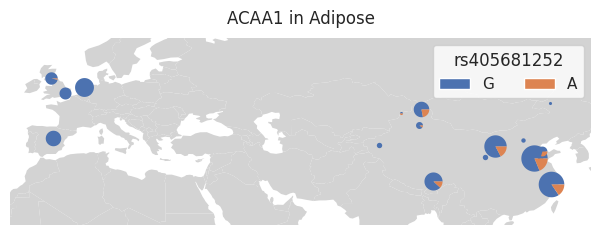

In [14]:
ax, legend_elements = plot_map(tpm_df2, ref2, alt2, variant_id2, title=f'{phenotype_id} in {tissue}', figsize=(7.5, 2.5))
ax.legend(handles=legend_elements, ncols=2, loc='upper right', title=rsid2)
plt.savefig('pdf/ACCAA1_breed_map.pdf', bbox_inches='tight')

In [15]:
tmm_df, corrected_tmm_df, ref, alt = load_group_tmm(tmm_file1, tmm_file2, batch_file1, batch_file2, vcf_file, group_file, phenotype_id, variant_id2)

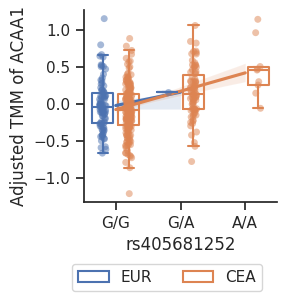

In [16]:
ax = plot_compare_tmm(corrected_tmm_df, variant_id2, grouplist=['EUR', 'CEA'], title=None, legend=True, figsize=(2.5, 2.5))
sns.move_legend(ax, "lower left", title=None, ncols=2, bbox_to_anchor=(-0.1, -0.5))
ax.set_xlabel(rsid2)
ax.set_ylabel(f'Adjusted TMM of {phenotype_id}')
plt.savefig('pdf/ACAA1_allele.pdf', bbox_inches='tight')

## Fig. 6d

In [17]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v9.breed_specific/v1.anc"
group1 = 'Europe'
group2 = 'Central_and_East_Asia'
group2abbr = {'Europe':'EUR', 'Central_and_East_Asia':'CEA'}
tissue = 'Liver'
phenotype_id = 'ABCB6'
variant_id1 = '2_221164733'
rsid1 = 'rs159573658'
variant_id2 = '2_221043333'
rsid2 = 'rs430521403'
chrom = 'chr' + variant_id1.split('_')[0]
tmm_file1 = f'{path}/{tissue}/phenotypes/{tissue}.{group1}.expression.bed.gz'
tmm_file2 = f'{path}/{tissue}/phenotypes/{tissue}.{group2}.expression.bed.gz'
batch_file1 = f'{path}/{tissue}/covFile/{tissue}.{group1}.tsv'
batch_file2 = f'{path}/{tissue}/covFile/{tissue}.{group2}.tsv'
vcf_file = f'{path}/{tissue}/genotypes/{tissue}.All.vcf.gz'
group_file = f"{path}/{tissue}/{tissue}.plot.grouplist"

In [18]:
nominal_file1 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group1}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file1 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group1}.cis_qtl_fdr0.05.txt.gz'
plink_prefix1 = f'{path}/{tissue}/genotypes/{tissue}.{group1}'
sample_size1 = dftis.loc[(dftis['Tissue']==tissue)&((dftis['group']==group1)), 'Sample size'].values[0]
ld_prefix1 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group1}'
title1 = f'{phenotype_id} in {tissue}\n({group2abbr[group1]}, n={sample_size1})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)

nominal_file2 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group2}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file2 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group2}.cis_qtl_fdr0.05.txt.gz'
plink_prefix2 = f'{path}/{tissue}/genotypes/{tissue}.{group2}'
sample_size2 = dftis.loc[(dftis['Tissue']==tissue)&((dftis['group']==group2)), 'Sample size'].values[0]
ld_prefix2 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group2}'
title2 = f'{phenotype_id} in {tissue}\n({group2abbr[group2]}, n={sample_size2})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)

locuszoom_df11, pval_nominal_threshold1, variant_id1 = load_qtl(nominal_file1, perm_file1, plink_prefix1, ld_prefix1, phenotype_id, variant_id=variant_id1)
locuszoom_df22, pval_nominal_threshold2, variant_id2 = load_qtl(nominal_file2, perm_file2, plink_prefix2, ld_prefix2, phenotype_id, variant_id=variant_id2)

locuszoom_df21, pval_nominal_threshold2, variant_id1 = load_qtl(nominal_file2, perm_file2, plink_prefix2, ld_prefix2, phenotype_id, variant_id=variant_id1)
locuszoom_df12, pval_nominal_threshold1, variant_id2 = load_qtl(nominal_file1, perm_file1, plink_prefix1, ld_prefix1, phenotype_id, variant_id=variant_id2)

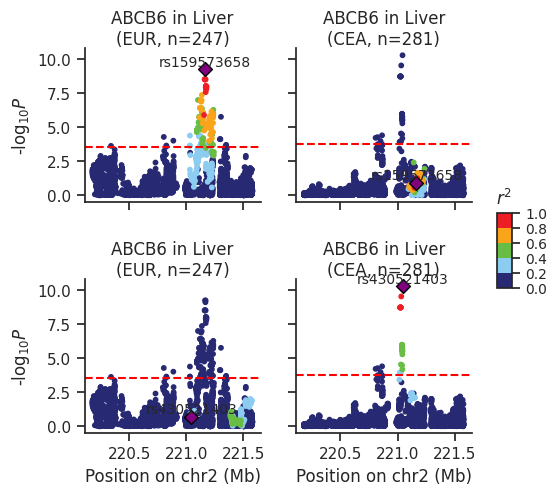

In [20]:
plot_compare_locus(locuszoom_df11, locuszoom_df12, locuszoom_df21, locuszoom_df22, pval_nominal_threshold1, pval_nominal_threshold2,
                   title1=title1, title2=title2, top_snp1=variant_id1, top_snp2=variant_id2, rsid1=rsid1, rsid2=rsid2, x_axis_range=None, y_axis_limit=None, figsize=(5, 5))
plt.savefig('ABCB6_breed.pdf', bbox_inches='tight')

## Fig. 6e

In [21]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v9.breed_specific/v1.anc"
group1 = 'Europe'
group2 = 'Central_and_East_Asia'
group2abbr = {'Europe':'EUR', 'Central_and_East_Asia':'CEA'}
tissue = 'Liver'
phenotype_id = 'RGS6'
variant_id = '7_82108418'
rsid = 'rs402321648'
chrom = 'chr' + variant_id.split('_')[0]
pos = int(variant_id.split('_')[1])
tmm_file1 = f'{path}/{tissue}/phenotypes/{tissue}.{group1}.expression.bed.gz'
tmm_file2 = f'{path}/{tissue}/phenotypes/{tissue}.{group2}.expression.bed.gz'
batch_file1 = f'{path}/{tissue}/covFile/{tissue}.{group1}.tsv'
batch_file2 = f'{path}/{tissue}/covFile/{tissue}.{group2}.tsv'
vcf_file = f'{path}/{tissue}/genotypes/{tissue}.All.vcf.gz'
group_file = f"{path}/{tissue}/{tissue}.plot.grouplist"

In [22]:
nominal_file1 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group1}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file1 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group1}.cis_qtl_fdr0.05.txt.gz'
plink_prefix1 = f'{path}/{tissue}/genotypes/{tissue}.{group1}'
sample_size1 = dftis.loc[(dftis['Tissue']==tissue)&((dftis['group']==group1)), 'Sample size'].values[0]
ld_prefix1 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group1}'
title1 = f'{phenotype_id} in {tissue}\n({group2abbr[group1]}, n={sample_size1})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)

nominal_file2 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group2}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file2 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group2}.cis_qtl_fdr0.05.txt.gz'
plink_prefix2 = f'{path}/{tissue}/genotypes/{tissue}.{group2}'
sample_size2 = dftis.loc[(dftis['Tissue']==tissue)&((dftis['group']==group2)), 'Sample size'].values[0]
ld_prefix2 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group2}'
title2 = f'{phenotype_id} in {tissue}\n({group2abbr[group2]}, n={sample_size2})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)

locuszoom_df11, pval_nominal_threshold1, variant_id = load_qtl(nominal_file1, perm_file1, plink_prefix1, ld_prefix1, phenotype_id, variant_id=variant_id)
locuszoom_df22, pval_nominal_threshold2, variant_id = load_qtl(nominal_file2, perm_file2, plink_prefix2, ld_prefix2, phenotype_id, variant_id=variant_id)

locuszoom_df21, pval_nominal_threshold2, variant_id = load_qtl(nominal_file2, perm_file2, plink_prefix2, ld_prefix2, phenotype_id, variant_id=variant_id)
locuszoom_df12, pval_nominal_threshold1, variant_id = load_qtl(nominal_file1, perm_file1, plink_prefix1, ld_prefix1, phenotype_id, variant_id=variant_id)

In [23]:
z = norm.ppf(1 - 0.05/2)

locuszoom_df1 = locuszoom_df11[locuszoom_df11['variant_id']==variant_id]
locuszoom_df1['group'] = group2abbr[group1]
locuszoom_df2 = locuszoom_df22[locuszoom_df22['variant_id']==variant_id]
locuszoom_df2['group'] = group2abbr[group2]

locuszoom_df = pd.concat([locuszoom_df1, locuszoom_df2])
locuszoom_df['Z'] = locuszoom_df['slope']/locuszoom_df['slope_se']
locuszoom_df['Z_se'] = 1
locuszoom_df['ci_lower'] = locuszoom_df['slope'] - z * locuszoom_df['slope_se']
locuszoom_df['ci_upper'] = locuszoom_df['slope'] + z * locuszoom_df['slope_se']
locuszoom_df['Z_ci_lower'] = locuszoom_df['Z'] - z * locuszoom_df['Z_se']
locuszoom_df['Z_ci_upper'] = locuszoom_df['Z'] + z * locuszoom_df['Z_se']
locuszoom_df

/tmp/ipykernel_1098825/2640216575.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locuszoom_df1['group'] = group2abbr[group1]
/tmp/ipykernel_1098825/2640216575.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locuszoom_df2['group'] = group2abbr[group2]


,phenotype_id,variant_id,slope,slope_se,pval_nominal,BP,R2,-log10(p-value),group,Z,Z_se,ci_lower,ci_upper,Z_ci_lower,Z_ci_upper
1519,RGS6,7_82108418,-0.675961,0.123716,1.262273e-07,82108418,1.0,6.898847,EUR,-5.463810,1,-0.91844,-0.433482,-7.423774,-3.503846
1519,RGS6,7_82108418,0.933342,0.155555,7.013922e-09,82108418,1.0,8.154039,CEA,6.000077,1,0.62846,1.238225,4.040113,7.960041


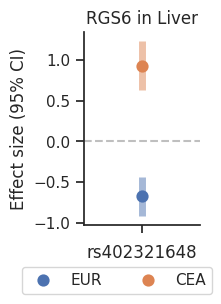

In [24]:
sns.set_theme(style="ticks")
plt.figure(figsize=(1.5, 2.5))
ax = sns.pointplot(data=locuszoom_df, y='slope', hue='group', errorbar=('ci', 95), linestyle='none')

# error bar
for i, (_, row) in enumerate(locuszoom_df.iterrows()):
    ax.errorbar(x=0, y=row['slope'], yerr=[[row['slope']-row['ci_lower']], [row['ci_upper']-row['slope']]], 
                fmt='none', elinewidth=5, color=sns.color_palette()[i], alpha=0.5)
ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
ax.set_xlabel(rsid)
ax.set_ylabel('Effect size (95% CI)')
ax.set_title(f'{phenotype_id} in {tissue}')
sns.move_legend(ax, "lower left", title=None, ncols=2, bbox_to_anchor=(-0.6, -0.4))
sns.despine()
plt.savefig('pdf/RGS6_effect_size.pdf', bbox_inches='tight')

In [25]:
tmm_df, corrected_tmm_df, ref, alt = load_group_tmm(tmm_file1, tmm_file2, batch_file1, batch_file2, vcf_file, group_file, phenotype_id, variant_id)

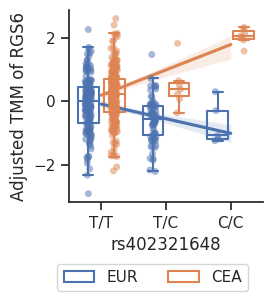

In [26]:
ax = plot_compare_tmm(corrected_tmm_df, variant_id, grouplist=['EUR', 'CEA'], title=None, legend=True, figsize=(2.5, 2.5))
sns.move_legend(ax, "lower left", title=None, ncols=2, bbox_to_anchor=(-0.1, -0.5))
ax.set_xlabel(rsid)
ax.set_ylabel(f'Adjusted TMM of {phenotype_id}')
plt.savefig('pdf/RGS6_allele.pdf', bbox_inches='tight')

# Fig. 6f-i

In [1]:
import numpy as np
import pandas as pd
from pysam import VariantFile
import scipy.stats as stats
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
%matplotlib inline
import seaborn as sns
import os

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## functions

In [3]:
def load_qtl(nominal_file, perm_file, plink_prefix, ld_prefix, phenotype_id, variant_id=None, x_axis_range=None):
    ## input summary data
    nominal_df = pd.read_csv(nominal_file, sep='\t')
    nominal_df = nominal_df[nominal_df['phenotype_id']==phenotype_id]
    nominal_df = nominal_df.dropna(subset=['pval_nominal'])
    if nominal_df.empty:
        warnings.warn("No valid pval_nominal values found for the specified phenotype_id.")
        return pd.DataFrame(), None, variant_id
    perm_df = pd.read_csv(perm_file, sep='\t')
    pval_nominal_threshold = perm_df[perm_df['phenotype_id']==phenotype_id]['pval_nominal_threshold'].values[0]

    ## input bim file
    bim_file = f'{plink_prefix}.bim'
    bim_df = pd.read_csv(bim_file, delim_whitespace=True, header=None, names=['CHR', 'SNP', 'CM', 'BP', 'ALT', 'REF'])

    ## merge data
    merged_nominal_df = pd.merge(nominal_df, bim_df, left_on='variant_id', right_on='SNP', how='left')

    # get the top snp
    if variant_id:
        if variant_id in merged_nominal_df['variant_id'].values:
            top_snp = variant_id
            top_snp_row = merged_nominal_df[merged_nominal_df['variant_id']==top_snp].iloc[0]
        else:
            warnings.warn(f"The specified SNP {variant_id} is not in the nominal results.")
            return pd.DataFrame(), pval_nominal_threshold, variant_id
    else:
        top_snp_row = merged_nominal_df.loc[merged_nominal_df['pval_nominal'].idxmin()]
        top_snp = top_snp_row['variant_id']
        variant_id = top_snp
    top_bp = int(top_snp_row['BP'])

    # compute LD
    if not os.path.isfile(f'{ld_prefix}.{variant_id}.ld'):
        cmd=f'''/storage/public/home/2020060185/bin/plink \\
            --bfile {plink_prefix} --ld-snp {top_snp} \\
            --sheep --keep-allele-order --r2 yes-really \\
            --ld-window-kb 999999 --ld-window 999999 --ld-window-r2 0 \\
            --out {ld_prefix}.{variant_id}'''
        os.system(cmd)
    ld_df = pd.read_csv(f'{ld_prefix}.{variant_id}.ld', delim_whitespace=True)
    ld_df = ld_df[['SNP_B', 'R2']]
    ld_df.columns = ['SNP', 'R2']
    ## merge data
    merged_df = pd.merge(merged_nominal_df, ld_df, left_on='variant_id', right_on='SNP', how='left')

    # set x axis range
    if x_axis_range:
        range_start = top_bp - x_axis_range
        range_end = top_bp + x_axis_range
        merged_df = merged_df[(merged_df['BP'] >= range_start) & (merged_df['BP'] <= range_end)]

    # prepare data for locusplot
    locuszoom_df = merged_df[['phenotype_id','variant_id','slope', 'slope_se', 'pval_nominal','BP','R2']].copy()
    locuszoom_df['-log10(p-value)'] = -np.log10(locuszoom_df['pval_nominal'])
    locuszoom_df = locuszoom_df.sort_values(by='R2', ascending=True)
    
    return locuszoom_df, pval_nominal_threshold, variant_id

In [4]:
def load_group_tpm(tpm, vcf_file, group_file, phenotype_id, variant_id):
    if not variant_id:
        warnings.warn("Variant {variant_id} does not exist!")
    chrom = 'chr' + variant_id.split('_')[0]
    position = int(variant_id.split('_')[1])
    # input genotpyes
    vcf_in = VariantFile(vcf_file)  # auto-detect input format

    rec_list = []
    for rec in vcf_in.fetch(chrom, position-1, position):
        rec_dict = {
            'chrom': rec.chrom,
            'pos': rec.pos,
            'id': rec.id,
            'ref': rec.ref,
            'alt': rec.alts[0]
        }
        for sample in rec.samples:
            rec_dict[sample] = sum(rec.samples[sample]['GT'])
        rec_list.append(rec_dict)

    genotype_df = pd.DataFrame(rec_list)
    genotype_s = genotype_df[genotype_df['id']==variant_id].iloc[0]

    # input phenotypes
    sample_list = genotype_s.index[5:].to_list()
    phenotype_df = tpm[sample_list]
    phenotype_s = phenotype_df.loc[phenotype_id]
    
    # input group
    group_df = pd.read_csv(group_file, sep="\t", index_col=0)

    # grouping
    df = pd.DataFrame({
        'phenotype': phenotype_s,
        'genotype': genotype_s[5:]
    })
    df = pd.merge(df, group_df, left_index=True, right_index=True)
    df = df[df['phenotype']>0]
    df['genotype'] = df['genotype'].astype(int)
    
    # rename
    df['log\u2082(TPM)'] = np.log2(df['phenotype'])
    ref = genotype_s['ref'] + '/' + genotype_s['ref']
    het = genotype_s['ref'] + '/' + genotype_s['alt']
    alt = genotype_s['alt'] + '/' + genotype_s['alt']
    df['genotype0'] = df['genotype'].replace({0:ref, 1:het, 2:alt})
    df = df.sort_values(by='genotype', ascending=True)
    return df, genotype_s['ref'], genotype_s['alt']


def plot_compare_tpm(df, variant_id, grouplist, figsize=(2.5, 2.5), title=None, legend=True, ax=None):
    if ax is None:
        sns.set_theme(style="ticks")
        fig, ax = plt.subplots(figsize=figsize)
    
    sns.stripplot(data=df, x='genotype0', y='log\u2082(TPM)', hue="group", hue_order=grouplist,
                       alpha=0.5, dodge=True, legend=False, ax=ax)
    
    sns.boxplot(data=df, x='genotype0', y='log\u2082(TPM)', hue="group", hue_order=grouplist,
                     gap=0.2, fill=False, legend=legend, showfliers=False, dodge=True, ax=ax)
    
    for i, group in enumerate(grouplist): 
        sns.regplot(data=df[df['group']==group], x='genotype', y='log\u2082(TPM)',
                    scatter=None, color=sns.color_palette()[i], ax=ax)

    ax.set_xlabel(variant_id)
    if legend:
        sns.move_legend(ax, "lower left", title=None, ncols=2, bbox_to_anchor=(-0.5, -0.6))
    if title:
        ax.set_title(title)
        
    sns.despine()
    
    return ax

In [5]:
#tpm_file = '/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/sheep.PCGlnc.gene.merged.tpm.txt'
#tpm = pd.read_csv(tpm_file, sep='\t', index_col=0)
#tpm

In [5]:
import statsmodels.api as sm

def removeBatchEffect(expr, covariates):
    """
    等效于 limma::removeBatchEffect()
    参数:
        expr: 表达矩阵 (样本×基因), DataFrame
        covariates: 协变量矩阵 (样本×PCs), DataFrame
    返回:
        去除批次效应后的矩阵
    """
    # 添加截距项
    X = sm.add_constant(covariates)
    residuals = pd.DataFrame(index=expr.index, columns=expr.columns)
    
    # 对每个基因做线性回归
    for gene in expr.columns:
        y = expr[gene]
        model = sm.OLS(y, X)
        results = model.fit()
        residuals[gene] = results.resid + results.params[0]  # 残差 + 截距
    
    return residuals


def load_group_tmm(tmm_file1, tmm_file2, batch_file1, batch_file2, vcf_file, group_file, phenotype_id, variant_id):
    if not variant_id:
        warnings.warn(f"Variant {variant_id} does not exist!")
    chrom = 'chr' + variant_id.split('_')[0]
    position = int(variant_id.split('_')[1])
    # input genotpyes
    vcf_in = VariantFile(vcf_file)  # auto-detect input format

    rec_list = []
    for rec in vcf_in.fetch(chrom, position-1, position):
        rec_dict = {
            'chrom': rec.chrom,
            'pos': rec.pos,
            'id': rec.id,
            'ref': rec.ref,
            'alt': rec.alts[0]
        }
        for sample in rec.samples:
            rec_dict[sample] = sum(rec.samples[sample]['GT'])
        rec_list.append(rec_dict)

    genotype_df = pd.DataFrame(rec_list)
    genotype_s = genotype_df[genotype_df['id']==variant_id].iloc[0]

    sample_list = genotype_s.index[5:].to_list()
    # input phenotype1 and batch1
    phenotype_df1 = pd.read_csv(tmm_file1, sep="\t", index_col=3)
    phenotype_df1 = phenotype_df1.iloc[:, 3:]
    phenotype_s1 = phenotype_df1.loc[phenotype_id]
    batch_df1 = pd.read_csv(batch_file1, sep="\t", index_col=0)
    corrected_phenotype_s1 = removeBatchEffect(phenotype_s1.to_frame(), batch_df1.T)
    
    # input phenotype2 and batch2
    phenotype_df2 = pd.read_csv(tmm_file2, sep="\t", index_col=3)
    phenotype_df2 = phenotype_df2.iloc[:, 3:]
    phenotype_s2 = phenotype_df2.loc[phenotype_id]
    batch_df2 = pd.read_csv(batch_file2, sep="\t", index_col=0)
    corrected_phenotype_s2 = removeBatchEffect(phenotype_s2.to_frame(), batch_df2.T)

    # merge phenotypes
    phenotype_s = pd.concat([phenotype_s1, phenotype_s2]).reindex(sample_list)
    corrected_phenotype_s = pd.concat([corrected_phenotype_s1, corrected_phenotype_s2]).reindex(sample_list).iloc[:, 0]
    
    # input group
    group_df = pd.read_csv(group_file, sep="\t", index_col=0)

    # grouping
    df = pd.DataFrame({'phenotype': phenotype_s, 'genotype': genotype_s[5:]})
    df = pd.merge(df, group_df, left_index=True, right_index=True)
    df['genotype'] = df['genotype'].astype(int)
    
    # rename
    ref = genotype_s['ref'] + '/' + genotype_s['ref']
    het = genotype_s['ref'] + '/' + genotype_s['alt']
    alt = genotype_s['alt'] + '/' + genotype_s['alt']
    df['genotype0'] = df['genotype'].replace({0:ref, 1:het, 2:alt})
    df = df.sort_values(by='genotype', ascending=True)

    # grouping (corrected matrix)
    corrected_df = pd.DataFrame({'phenotype': corrected_phenotype_s, 'genotype': genotype_s[5:]})
    corrected_df = pd.merge(corrected_df, group_df, left_index=True, right_index=True)
    corrected_df['genotype'] = corrected_df['genotype'].astype(int)
    
    # rename (corrected matrix)
    corrected_df['genotype0'] = corrected_df['genotype'].replace({0:ref, 1:het, 2:alt})
    corrected_df = corrected_df.sort_values(by='genotype', ascending=True)
    
    return df, corrected_df, genotype_s['ref'], genotype_s['alt']


def plot_compare_tmm(df, variant_id, grouplist, figsize=(2.5, 2.5), title=None, legend=True, ax=None):
    if ax is None:
        sns.set_theme(style="ticks")
        fig, ax = plt.subplots(figsize=figsize)
    
    sns.stripplot(data=df, x='genotype0', y='phenotype', hue="group", hue_order=grouplist,
                       alpha=0.5, dodge=True, legend=False, ax=ax)
    
    sns.boxplot(data=df, x='genotype0', y='phenotype', hue="group", hue_order=grouplist,
                     gap=0.2, fill=False, legend=legend, showfliers=False, dodge=True, ax=ax)
    
    for i, group in enumerate(grouplist): 
        sns.regplot(data=df[df['group']==group], x='genotype', y='phenotype',
                    scatter=None, color=sns.color_palette()[i], ax=ax)

    ax.set_xlabel(variant_id)
    if legend:
        sns.move_legend(ax, "lower left", title=None, ncols=2, bbox_to_anchor=(-0.5, -0.6))
    if title:
        ax.set_title(title)
        
    sns.despine()
    
    return ax

## Fig. 6f

In [2]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v10.sex_specific"
dftis = pd.read_csv(f'{path}/tissue.filtered.list', sep='\t')
dfgroup = pd.melt(dftis, id_vars=['Tissue'], value_vars=['Female', 'Male'], 
           var_name='group', value_name='Sample size')
tislist = list(dftis['Tissue'])
tisorder = pd.read_csv("/storage/public/home/2020060185/jupyter/GTEx/00.metadata/tissue.order",sep="\t")
palette = tisorder.set_index('Tissue (QTL)')['Color'].to_dict()

In [3]:
qtl_sex = pd.read_csv(f"{path}/he_eqtl.txt", sep="\t")
egene_sex = qtl_sex[['tissue', 'pheno_id']].drop_duplicates()
egene_sex_count = egene_sex.groupby('tissue').count().reset_index().sort_values(by='pheno_id', ascending=False)
egene_sex_count = pd.merge(egene_sex_count, dftis, left_on='tissue', right_on='Tissue')
egene_sex_count

,tissue,pheno_id,Tissue,All,Female,Male
0,Pituitary,42,Pituitary,284,165,119
1,Brain,34,Brain,481,326,155
2,Heart,9,Heart,208,131,77
3,Liver,8,Liver,567,239,328
4,Blood,5,Blood,150,84,66
5,Longissimus_muscle,4,Longissimus_muscle,419,73,346
6,Muscle,4,Muscle,713,293,420
7,Lung,2,Lung,236,157,79
8,Rumen,2,Rumen,347,227,120
9,Subcutaneous_adipose,1,Subcutaneous_adipose,190,140,50


In [6]:
egene_sex_count['pheno_id'].mean()

6.9411764705882355

/tmp/ipykernel_1098534/454243201.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels)


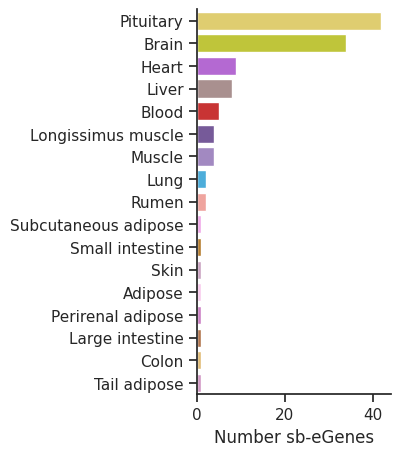

In [7]:
sns.set_theme(style="ticks")
fig=plt.figure(figsize=(2.5, 5))

ax = sns.barplot(egene_sex_count, y="tissue", x="pheno_id", palette=palette)
new_labels = [label.get_text().replace('_', ' ') for label in ax.get_yticklabels()]
ax.set_yticklabels(new_labels)
plt.xlabel('Number sb-eGenes')
plt.ylabel('')
plt.savefig('pdf/sb-egene-tissue.pdf', bbox_inches='tight')
sns.despine()

## Fig. 6g

In [15]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v10.sex_specific"
group1 = 'Female'
group2 = 'Male'
tissue = 'Adipose'
phenotype_id = 'TNC'
variant_id = '2_9627308'
rsid = 'rs422946288'
chrom = 'chr' + variant_id.split('_')[0]
pos = int(variant_id.split('_')[1])
tmm_file1 = f'{path}/{tissue}/phenotypes/{tissue}.{group1}.expression.bed.gz'
tmm_file2 = f'{path}/{tissue}/phenotypes/{tissue}.{group2}.expression.bed.gz'
batch_file1 = f'{path}/{tissue}/covFile/{tissue}.{group1}.tsv'
batch_file2 = f'{path}/{tissue}/covFile/{tissue}.{group2}.tsv'
vcf_file = f'{path}/{tissue}/genotypes/{tissue}.All.vcf.gz'
group_file = f"{path}/{tissue}/{tissue}.plot.grouplist"

In [16]:
nominal_file1 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group1}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file1 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group1}.cis_qtl_fdr0.05.txt.gz'
plink_prefix1 = f'{path}/{tissue}/genotypes/{tissue}.{group1}'
sample_size1 = dfgroup.loc[(dfgroup['Tissue']==tissue)&((dfgroup['group']==group1)), 'Sample size'].values[0]
ld_prefix1 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group1}'
title1 = f'{phenotype_id} in {tissue} ({group1}, n={sample_size1})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)
locuszoom_df1, pval_nominal_threshold1, variant_id = load_qtl(nominal_file1, perm_file1, plink_prefix1, ld_prefix1, phenotype_id, variant_id=variant_id)

nominal_file2 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group2}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file2 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group2}.cis_qtl_fdr0.05.txt.gz'
plink_prefix2 = f'{path}/{tissue}/genotypes/{tissue}.{group2}'
sample_size2 = dfgroup.loc[(dfgroup['Tissue']==tissue)&((dfgroup['group']==group2)), 'Sample size'].values[0]
ld_prefix2 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group2}'
title2 = f'{phenotype_id} in {tissue} ({group2}, n={sample_size2})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)
locuszoom_df2, pval_nominal_threshold2, variant_id = load_qtl(nominal_file2, perm_file2, plink_prefix2, ld_prefix2, phenotype_id, variant_id=variant_id)

In [17]:
z = norm.ppf(1 - 0.05/2)
locuszoom_dfv1 = locuszoom_df1[locuszoom_df1['variant_id']==variant_id]
locuszoom_dfv1['group'] = group1
locuszoom_dfv2 = locuszoom_df2[locuszoom_df2['variant_id']==variant_id]
locuszoom_dfv2['group'] = group2

locuszoom_dfv = pd.concat([locuszoom_dfv1, locuszoom_dfv2])
locuszoom_dfv['Z'] = locuszoom_dfv['slope']/locuszoom_dfv['slope_se']
locuszoom_dfv['Z_se'] = 1
locuszoom_dfv['ci_lower'] = locuszoom_dfv['slope'] - z * locuszoom_dfv['slope_se']
locuszoom_dfv['ci_upper'] = locuszoom_dfv['slope'] + z * locuszoom_dfv['slope_se']
locuszoom_dfv['Z_ci_lower'] = locuszoom_dfv['Z'] - z * locuszoom_dfv['Z_se']
locuszoom_dfv['Z_ci_upper'] = locuszoom_dfv['Z'] + z * locuszoom_dfv['Z_se']
locuszoom_dfv

/tmp/ipykernel_1098534/3146726487.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locuszoom_dfv1['group'] = group1
/tmp/ipykernel_1098534/3146726487.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locuszoom_dfv2['group'] = group2


,phenotype_id,variant_id,slope,slope_se,pval_nominal,BP,R2,-log10(p-value),group,Z,Z_se,ci_lower,ci_upper,Z_ci_lower,Z_ci_upper
3601,TNC,2_9627308,0.172656,0.089906,5.578766e-02,9627308,1.0,1.253462,Female,1.920402,1,-0.003557,0.348870,-0.039562,3.880366
3601,TNC,2_9627308,-0.685919,0.103785,6.451755e-10,9627308,1.0,9.190322,Male,-6.609062,1,-0.889333,-0.482505,-8.569026,-4.649098


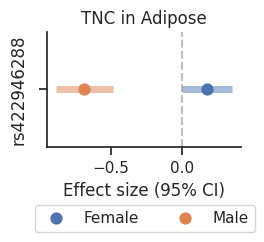

In [18]:
tisname = ' '.join(tissue.split('_'))
sns.set_theme(style="ticks")
plt.figure(figsize=(2.5, 1.5))
ax = sns.pointplot(data=locuszoom_dfv, x='slope', hue='group', errorbar=('ci', 95), linestyle='none')

# error bar
for i, (_, row) in enumerate(locuszoom_dfv.iterrows()):
    ax.errorbar(y=0, x=row['slope'], xerr=[[row['slope']-row['ci_lower']], [row['ci_upper']-row['slope']]], 
                fmt='none', elinewidth=5, color=sns.color_palette()[i], alpha=0.5)
ax.axvline(0, color='grey', linestyle='--', alpha=0.5)
ax.set_ylabel(rsid)
ax.set_xlabel('Effect size (95% CI)')
ax.set_title(f'{phenotype_id} in {tisname}')
sns.move_legend(ax, "lower left", title=None, ncols=2, bbox_to_anchor=(-0.1, -0.8))
sns.despine()
plt.savefig('pdf/TNC_effect_size.pdf', bbox_inches='tight')

In [19]:
tmm_df, corrected_tmm_df, ref, alt = load_group_tmm(tmm_file1, tmm_file2, batch_file1, batch_file2, vcf_file, group_file, phenotype_id, variant_id)

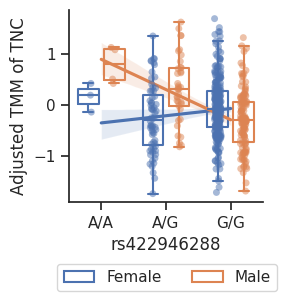

In [20]:
ax = plot_compare_tmm(corrected_tmm_df, variant_id, grouplist=['Female', 'Male'], title=None, legend=True, figsize=(2.5, 2.5))
sns.move_legend(ax, "lower left", title=None, ncols=2, bbox_to_anchor=(-0.1, -0.5))
ax.set_xlabel(rsid)
ax.set_ylabel(f'Adjusted TMM of {phenotype_id}')
plt.savefig('pdf/TNC_sex.pdf', bbox_inches='tight')

## Fig. 6h

In [6]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v11.stage_specific"
dftis = pd.read_csv(f'{path}/tissue.filtered.list', sep='\t')
dfgroup = pd.melt(dftis, id_vars=['Tissue'], value_vars=['Adult', 'Lamb'], 
           var_name='group', value_name='Sample size')
tislist = list(dftis['Tissue'])
tisorder = pd.read_csv("/storage/public/home/2020060185/jupyter/GTEx/00.metadata/tissue.order",sep="\t")
palette = tisorder.set_index('Tissue (QTL)')['Color'].to_dict()

In [7]:
qtl_stage = pd.read_csv(f"{path}/he_eqtl.txt", sep="\t")
egene_stage = qtl_stage[['tissue', 'pheno_id']].drop_duplicates()
egene_stage_count = egene_stage.groupby('tissue').count().reset_index().sort_values(by='pheno_id', ascending=False)
egene_stage_count = pd.merge(egene_stage_count, dftis, left_on='tissue', right_on='Tissue')
egene_stage_count

,tissue,pheno_id,Tissue,All,Adult,Lamb,Prenatal
0,Adenohypophysis,34,Adenohypophysis,116,50,66,0
1,Pituitary,29,Pituitary,284,177,106,1
2,Blood,15,Blood,150,62,88,0
3,Brain,9,Brain,481,298,160,23
4,Muscle,9,Muscle,713,179,476,58
5,Abomasum,7,Abomasum,228,77,151,0
6,Perirenal_adipose,7,Perirenal_adipose,207,109,77,21
7,Liver,6,Liver,567,137,416,14
8,Lung,6,Lung,236,125,92,19
9,Ileum,5,Ileum,178,110,64,4


/tmp/ipykernel_1098534/3225666057.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(new_labels)


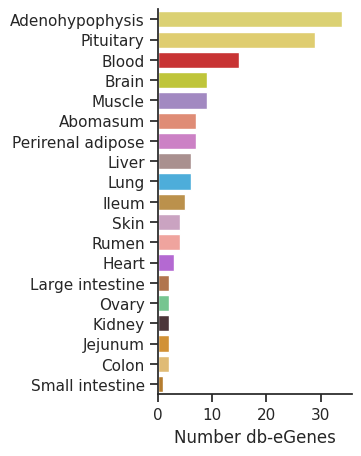

In [23]:
sns.set_theme(style="ticks")
fig=plt.figure(figsize=(2.5, 5))

ax = sns.barplot(egene_stage_count, y="tissue", x="pheno_id", palette=palette)
new_labels = [label.get_text().replace('_', ' ') for label in ax.get_yticklabels()]
ax.set_yticklabels(new_labels)
plt.xlabel('Number db-eGenes')
plt.ylabel('')
sns.despine()
plt.savefig('pdf/db-egene-tissue.pdf', bbox_inches='tight')

## Fig. 6i

In [9]:
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v11.stage_specific"
group1 = 'Adult'
group2 = 'Lamb'
tissue = 'Adenohypophysis'
phenotype_id = 'AADACL3'
variant_id = '12_54156577'
rsid = 'rs406388696'
chrom = 'chr' + variant_id.split('_')[0]
pos = int(variant_id.split('_')[1])
tmm_file1 = f'{path}/{tissue}/phenotypes/{tissue}.{group1}.expression.bed.gz'
tmm_file2 = f'{path}/{tissue}/phenotypes/{tissue}.{group2}.expression.bed.gz'
batch_file1 = f'{path}/{tissue}/covFile/{tissue}.{group1}.tsv'
batch_file2 = f'{path}/{tissue}/covFile/{tissue}.{group2}.tsv'
vcf_file = f'{path}/{tissue}/genotypes/{tissue}.All.vcf.gz'
group_file = f"{path}/{tissue}/{tissue}.plot.grouplist"

In [10]:
nominal_file1 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group1}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file1 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group1}.cis_qtl_fdr0.05.txt.gz'
plink_prefix1 = f'{path}/{tissue}/genotypes/{tissue}.{group1}'
sample_size1 = dfgroup.loc[(dfgroup['Tissue']==tissue)&((dfgroup['group']==group1)), 'Sample size'].values[0]
ld_prefix1 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group1}'
title1 = f'{phenotype_id} in {tissue} ({group1}, n={sample_size1})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)
locuszoom_df1, pval_nominal_threshold1, variant_id = load_qtl(nominal_file1, perm_file1, plink_prefix1, ld_prefix1, phenotype_id, variant_id=variant_id)

nominal_file2 = f'{path}/{tissue}/results/tensorqtl/nominal/{tissue}.{group2}.cis_qtl_pairs.{chrom}.txt.gz'
perm_file2 = f'{path}/{tissue}/results/tensorqtl/permutation/{tissue}.{group2}.cis_qtl_fdr0.05.txt.gz'
plink_prefix2 = f'{path}/{tissue}/genotypes/{tissue}.{group2}'
sample_size2 = dfgroup.loc[(dfgroup['Tissue']==tissue)&((dfgroup['group']==group2)), 'Sample size'].values[0]
ld_prefix2 = f'{path}/{tissue}/local/locuszoom/{phenotype_id}/{phenotype_id}.{group2}'
title2 = f'{phenotype_id} in {tissue} ({group2}, n={sample_size2})'
os.makedirs(f'{path}/{tissue}/local/locuszoom/{phenotype_id}', exist_ok=True)
locuszoom_df2, pval_nominal_threshold2, variant_id = load_qtl(nominal_file2, perm_file2, plink_prefix2, ld_prefix2, phenotype_id, variant_id=variant_id)

In [11]:
locuszoom_dfv1 = locuszoom_df1[locuszoom_df1['variant_id']==variant_id]
locuszoom_dfv1['group'] = group1
locuszoom_dfv2 = locuszoom_df2[locuszoom_df2['variant_id']==variant_id]
locuszoom_dfv2['group'] = group2

locuszoom_dfv = pd.concat([locuszoom_dfv1, locuszoom_dfv2])
locuszoom_dfv['Z'] = locuszoom_dfv['slope']/locuszoom_dfv['slope_se']
locuszoom_dfv['Z_se'] = 1
locuszoom_dfv['ci_lower'] = locuszoom_dfv['slope'] - 1.96 * locuszoom_dfv['slope_se']
locuszoom_dfv['ci_upper'] = locuszoom_dfv['slope'] + 1.96 * locuszoom_dfv['slope_se']
locuszoom_dfv['Z_ci_lower'] = locuszoom_dfv['Z'] - 1.96 * locuszoom_dfv['Z_se']
locuszoom_dfv['Z_ci_upper'] = locuszoom_dfv['Z'] + 1.96 * locuszoom_dfv['Z_se']
locuszoom_dfv

/tmp/ipykernel_921/2800432198.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locuszoom_dfv1['group'] = group1
/tmp/ipykernel_921/2800432198.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locuszoom_dfv2['group'] = group2


,phenotype_id,variant_id,slope,slope_se,pval_nominal,BP,R2,-log10(p-value),group,Z,Z_se,ci_lower,ci_upper,Z_ci_lower,Z_ci_upper
393,AADACL3,12_54156577,0.689618,0.182716,5.213365e-04,54156577,1.0,3.282882,Adult,3.774254,1,0.331494,1.047743,1.814254,5.734254
393,AADACL3,12_54156577,-0.663362,0.110620,2.214241e-07,54156577,1.0,6.654775,Lamb,-5.996787,1,-0.880176,-0.446548,-7.956787,-4.036787


In [12]:
z = norm.ppf(1 - 0.05/2)
locuszoom_dfv1 = locuszoom_df1[locuszoom_df1['variant_id']==variant_id]
locuszoom_dfv1['group'] = group1
locuszoom_dfv2 = locuszoom_df2[locuszoom_df2['variant_id']==variant_id]
locuszoom_dfv2['group'] = group2

locuszoom_dfv = pd.concat([locuszoom_dfv1, locuszoom_dfv2])
locuszoom_dfv['Z'] = locuszoom_dfv['slope']/locuszoom_dfv['slope_se']
locuszoom_dfv['Z_se'] = 1
locuszoom_dfv['ci_lower'] = locuszoom_dfv['slope'] - z * locuszoom_dfv['slope_se']
locuszoom_dfv['ci_upper'] = locuszoom_dfv['slope'] + z * locuszoom_dfv['slope_se']
locuszoom_dfv['Z_ci_lower'] = locuszoom_dfv['Z'] - z * locuszoom_dfv['Z_se']
locuszoom_dfv['Z_ci_upper'] = locuszoom_dfv['Z'] + z * locuszoom_dfv['Z_se']
locuszoom_dfv

/tmp/ipykernel_921/3146726487.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locuszoom_dfv1['group'] = group1
/tmp/ipykernel_921/3146726487.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locuszoom_dfv2['group'] = group2


,phenotype_id,variant_id,slope,slope_se,pval_nominal,BP,R2,-log10(p-value),group,Z,Z_se,ci_lower,ci_upper,Z_ci_lower,Z_ci_upper
393,AADACL3,12_54156577,0.689618,0.182716,5.213365e-04,54156577,1.0,3.282882,Adult,3.774254,1,0.331501,1.047736,1.814290,5.734218
393,AADACL3,12_54156577,-0.663362,0.110620,2.214241e-07,54156577,1.0,6.654775,Lamb,-5.996787,1,-0.880172,-0.446552,-7.956751,-4.036823


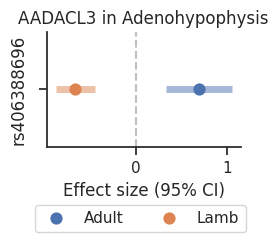

In [13]:
tisname = ' '.join(tissue.split('_'))
sns.set_theme(style="ticks")
plt.figure(figsize=(2.5, 1.5))
ax = sns.pointplot(data=locuszoom_dfv, x='slope', hue='group', errorbar=('ci', 95), linestyle='none')

# error bar
for i, (_, row) in enumerate(locuszoom_dfv.iterrows()):
    ax.errorbar(y=0, x=row['slope'], xerr=[[row['slope']-row['ci_lower']], [row['ci_upper']-row['slope']]], 
                fmt='none', elinewidth=5, color=sns.color_palette()[i], alpha=0.5)
ax.axvline(0, color='grey', linestyle='--', alpha=0.5)
ax.set_ylabel(rsid)
ax.set_xlabel('Effect size (95% CI)')
ax.set_title(f'{phenotype_id} in {tisname}')
sns.move_legend(ax, "lower left", title=None, ncols=2, bbox_to_anchor=(-0.1, -0.8))
sns.despine()
plt.savefig('pdf/AADACL3_effect_size.pdf', bbox_inches='tight')

In [27]:
tmm_df, corrected_tmm_df, ref, alt = load_group_tmm(tmm_file1, tmm_file2, batch_file1, batch_file2, vcf_file, group_file, phenotype_id, variant_id)

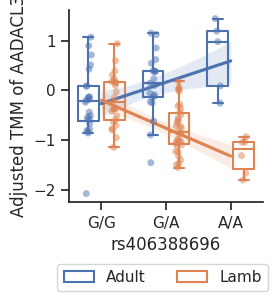

In [28]:
ax = plot_compare_tmm(corrected_tmm_df, variant_id, grouplist=['Adult', 'Lamb'], title=None, legend=True, figsize=(2.5, 2.5))
sns.move_legend(ax, "lower left", title=None, ncols=2, bbox_to_anchor=(-0.1, -0.5))
ax.set_xlabel(rsid)
ax.set_ylabel(f'Adjusted TMM of {phenotype_id}')
plt.savefig('pdf/AADACL3_allele.pdf', bbox_inches='tight')